# Hotel Review Topic Modeling
**Language Analytics - Yelp Hotel Reviews**

Goal: Identify what topics unhappy hotel reviewers bring up so a new hotel can proactively focus on high-risk service areas.

## 1. Setup & Imports

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
PALETTE = {'unhappy': '#E04040', 'neutral': '#F5A623', 'happy': '#2E8B57'}
RATING_COLORS = ['#E04040', '#E07840', '#F5A623', '#7EB87E', '#2E8B57']

print('All imports successful.')

All imports successful.


## 2. Load & Explore Data

In [121]:
df = pd.read_csv('hotel_final.csv', index_col=0)
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
df.head(3)

Shape: (949, 6)


,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0


In [122]:
total = df.shape[0]
print('=' * 54)
print('DATASET OVERVIEW')
print('=' * 54)
print(f'  Total reviews:      {total:,}')
print(f'  Features:           {df.shape[1]}')
print(f'  Missing values:     {df.isnull().sum().sum()}')
print(f'  Average rating:     {df["rating"].mean():.2f}')
print()
print('Star rating breakdown:')
for r, cnt in df['rating'].value_counts().sort_index().items():
    print(f'  {r}★  {cnt:>3} reviews  ({cnt/total:.0%})')
print()

DATASET OVERVIEW
  Total reviews:      949
  Features:           6
  Missing values:     0
  Average rating:     3.48

Star rating breakdown:
  1★   81 reviews  (9%)
  2★  121 reviews  (13%)
  3★  207 reviews  (22%)
  4★  341 reviews  (36%)
  5★  199 reviews  (21%)



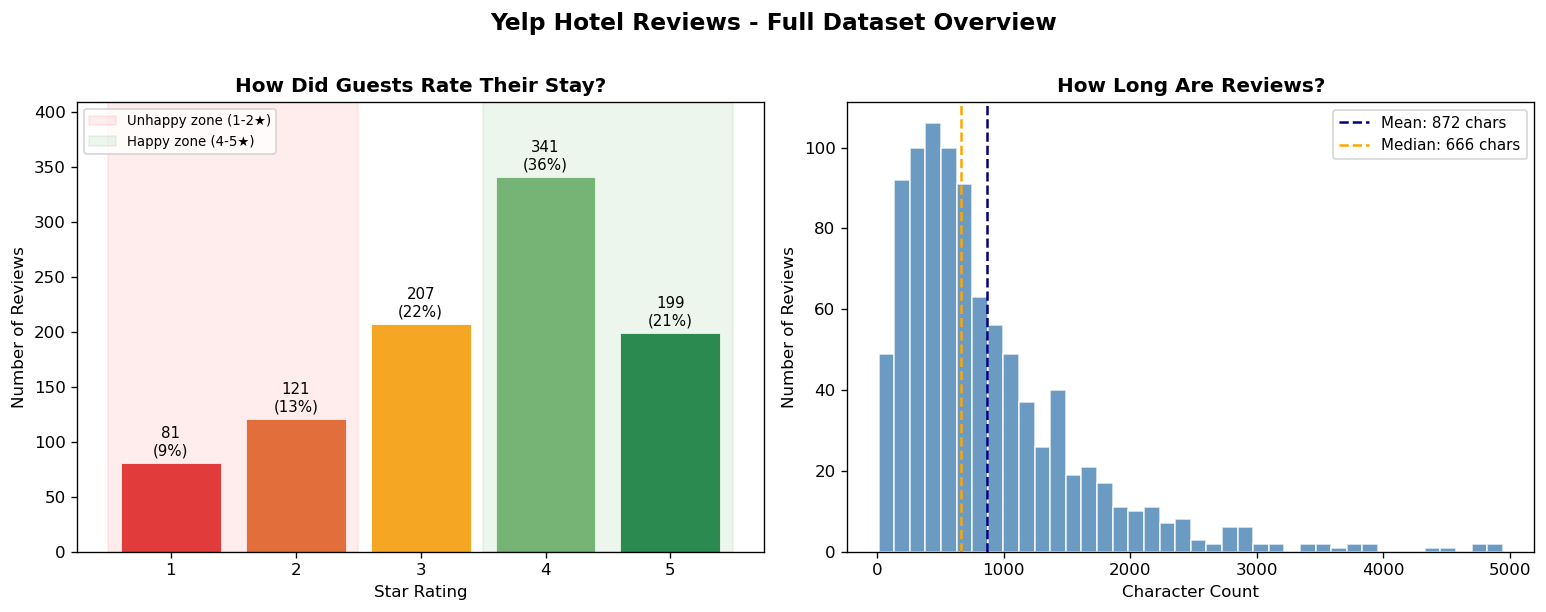

In [123]:
# --- Visualization: Rating distribution and review length ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Yelp Hotel Reviews - Full Dataset Overview',
             fontsize=14, fontweight='bold', y=1.01)

# --- Left: Rating distribution ---
rating_counts = df['rating'].value_counts().sort_index()
colors = RATING_COLORS
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                   color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('How Did Guests Rate Their Stay?', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, rating_counts.max() * 1.20)
for x, y in zip(rating_counts.index, rating_counts.values):
    pct = y / len(df) * 100
    axes[0].text(x, y + 4, f'{y}\n({pct:.0f}%)', ha='center', fontsize=9, va='bottom')
axes[0].axvspan(0.5, 2.5, alpha=0.07, color='red', label='Unhappy zone (1-2★)')
axes[0].axvspan(3.5, 5.5, alpha=0.07, color='green', label='Happy zone (4-5★)')
axes[0].legend(fontsize=8, loc='upper left')

# --- Right: Review length distribution ---
df['review_length'] = df['reviewContent'].str.len()
mean_len = df['review_length'].mean()
med_len  = df['review_length'].median()
axes[1].hist(df['review_length'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(mean_len, color='navy',   linestyle='--', linewidth=1.5, label=f'Mean: {mean_len:.0f} chars')
axes[1].axvline(med_len,  color='orange', linestyle='--', linewidth=1.5, label=f'Median: {med_len:.0f} chars')
axes[1].set_title('How Long Are Reviews?', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_data_overview.png', bbox_inches='tight')
plt.show()

## 3. Segment Reviews: Happy vs. Unhappy

In [124]:
# Unhappy: 1-2 stars | Neutral: 3 stars | Happy: 4-5 stars
def sentiment_label(r):
    if r <= 2: return 'unhappy'
    elif r == 3: return 'neutral'
    else: return 'happy'

df['sentiment'] = df['rating'].apply(sentiment_label)

total     = len(df)
n_unhappy = (df['sentiment'] == 'unhappy').sum()
n_neutral = (df['sentiment'] == 'neutral').sum()
n_happy   = (df['sentiment'] == 'happy').sum()

print('=' * 54)
print('REVIEW SEGMENTS FOR ANALYSIS')
print('=' * 54)
print(f'  Unhappy  (1-2★):  {n_unhappy:>3} reviews  ({n_unhappy/total:.1%})')
print(f'  Neutral   (3★):   {n_neutral:>3} reviews  ({n_neutral/total:.1%})')
print(f'  Happy   (4-5★):   {n_happy:>3} reviews  ({n_happy/total:.1%})')
print()

REVIEW SEGMENTS FOR ANALYSIS
  Unhappy  (1-2★):  202 reviews  (21.3%)
  Neutral   (3★):   207 reviews  (21.8%)
  Happy   (4-5★):   540 reviews  (56.9%)



## 4. Text Preprocessing

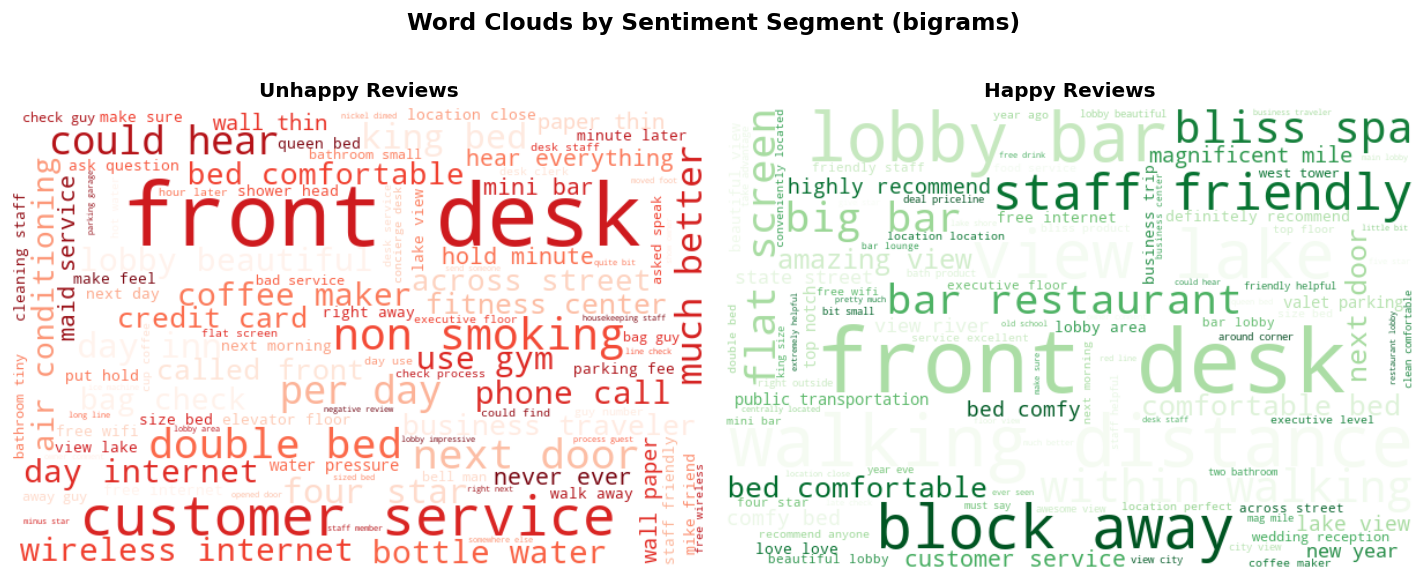

In [125]:
import wordcloud
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add domain-specific stopwords that don't carry topic signal
extra_stops = {
    'hotel', 'stay', 'room', 'place', 'get', 'got', 'one', 'would',
    'also', 'really', 'even', 'us', 'back', 'went', 'go', 'time',
    'the', 'a', 'an', 'and', 'or', 'but', 'i', 'we', 'they', 'it',
    'w', 'wa', 'like', 'good', 'great', 'nice', 'n', 'chicago', 'palmer', 
    'millennium', 'park', 'navy', 'pier', 'palmer', 'house', 'michigan', 'ave', 
    'hotel', 'room', 'rooms', 'stay', 'stayed', 'great', 'good', 'nice', 
    'really', 'just', 'like', 'did', 'dont', 'didnt', 'got', 'went', 
    'come', 'came', 'chicago', 'time', 'place', 'night', 'institute', 
    'hyatt', 'regency'
}
stop_words.update(extra_stops)

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text) # keep only letters
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['reviewContent'].apply(preprocess)

# Word clouds using bigram frequencies
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Word Clouds by Sentiment Segment (bigrams)',
             fontsize=14, fontweight='bold', y=1.01)
segments = ['unhappy', 'happy']
for i, seg in enumerate(segments):
    texts = df[df['sentiment'] == seg]['clean_text'].tolist()

    # Build bigram frequency dict for this segment
    vec = CountVectorizer(ngram_range=(2, 2), max_features=200)
    dtm = vec.fit_transform(texts)
    freqs = dict(zip(vec.get_feature_names_out(), dtm.sum(axis=0).A1))

    wc = wordcloud.WordCloud(width=600, height=400, background_color='white',
                   colormap='Reds' if seg == 'unhappy' else 'Greens' if seg == 'happy' else 'Greys',
                   max_words=100).generate_from_frequencies(freqs)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{seg.capitalize()} Reviews', fontsize=12, fontweight='bold')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('fig2_wordclouds.png', bbox_inches='tight')
plt.show()

## 5. Topic Modeling - All Reviews (LDA)

In [126]:
# --- Topic Modeling: LDA on full dataset ---
N_TOPICS = 5
N_TOP_WORDS = 12

vectorizer_all = CountVectorizer(
    max_df=0.90,
    min_df=5,
    max_features=2000,
    ngram_range=(2, 3)
)

dtm_all = vectorizer_all.fit_transform(df['clean_text'])

lda_all = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=20,
    learning_method='online'
)
lda_all.fit(dtm_all)

print(f'LDA model trained - {N_TOPICS} topics extracted from {dtm_all.shape[0]:,} reviews')
print(f'  Vocabulary: {dtm_all.shape[1]:,} unique terms (two-word + three-word phrases)')
print(f'  Perplexity: {lda_all.perplexity(dtm_all):.0f} (lower is better)')

LDA model trained - 5 topics extracted from 949 reviews
  Vocabulary: 544 unique terms (two-word + three-word phrases)
  Perplexity: 664 (lower is better)


In [127]:
# Labels derived from inspecting actual (2,3)-ngram top phrases printed below.
TOPIC_LABELS_ALL = {
    0: 'Service Quality & Experience',   
    1: 'Walkability & Location',     
    2: 'Amenities',   
    3: 'Room Quality',        
    4: 'Front Desk & Staff',                   
}

feature_names = vectorizer_all.get_feature_names_out()

def print_topics(model, feature_names, labels, n_top=15):
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top-1:-1]]
        print(f"  Topic {idx} | {labels.get(idx, '?')}")
        print(f"  Phrases: {', '.join(top_words)}")
        print()

print('=== TOP PHRASES PER TOPIC - ALL REVIEWS (ngram 2-3) ===\n')
print_topics(lda_all, feature_names, TOPIC_LABELS_ALL)

=== TOP PHRASES PER TOPIC - ALL REVIEWS (ngram 2-3) ===

  Topic 0 | Service Quality & Experience
  Phrases: view lake, magnificent mile, customer service, lobby area, make sure, top floor, much better, bed comfy, bliss product, late check, next day, mini bar, sized bed, flat screen, location location

  Topic 1 | Walkability & Location
  Phrases: walking distance, block away, comfortable bed, front desk, big bar, within walking, within walking distance, across street, view river, next morning, year ago, lake view, phone call, free wifi, bar lounge

  Topic 2 | Amenities
  Phrases: lobby bar, comfy bed, highly recommend, bar restaurant, executive floor, size bed, little small, amazing view, bar lobby, free internet, business center, pretty cool, use gym, king size, right middle

  Topic 3 | Room Quality
  Phrases: staff friendly, double bed, beautiful lobby, coffee maker, next door, new year, queen bed, wireless internet, state street, king bed, fitness center, year eve, new year eve, 

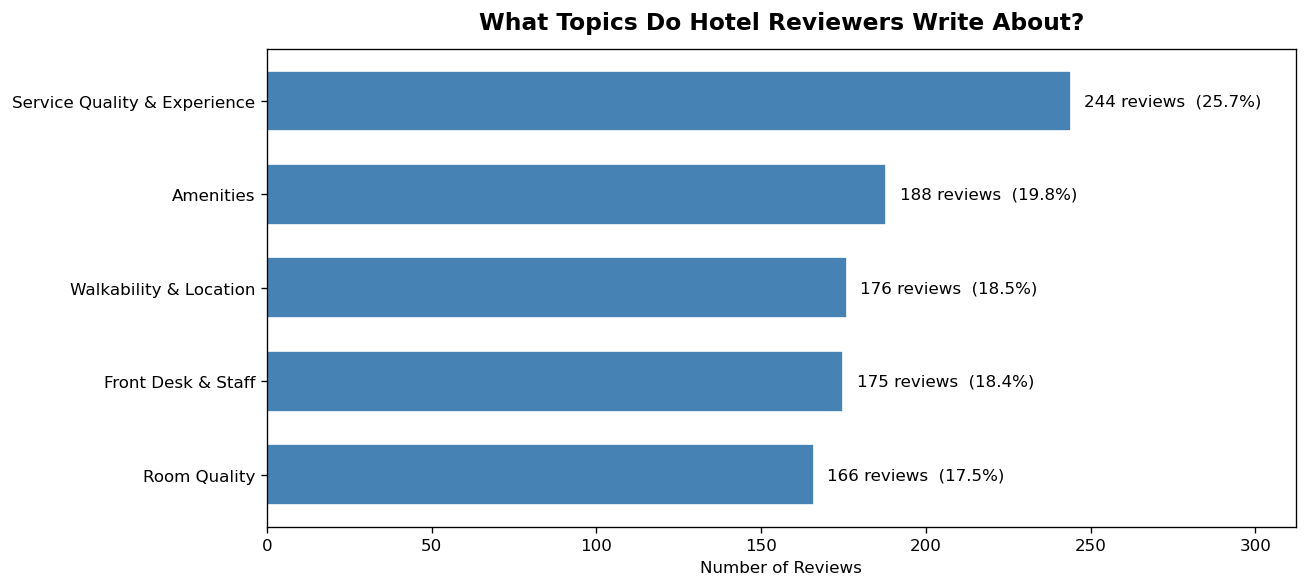

In [128]:
# Assign dominant topic to each review
doc_topic_all = lda_all.transform(dtm_all)
df['dominant_topic'] = doc_topic_all.argmax(axis=1)
df['dominant_topic_label'] = df['dominant_topic'].map(TOPIC_LABELS_ALL)

# Overall topic prevalence
topic_counts = df['dominant_topic_label'].value_counts().sort_values(ascending=True)
topic_pcts   = (topic_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(topic_counts.index, topic_counts.values,
               color='steelblue', edgecolor='white', height=0.65)
ax.set_title('What Topics Do Hotel Reviewers Write About?',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Reviews')
ax.set_xlim(0, topic_counts.values.max() * 1.28)

for bar, cnt, pct in zip(bars, topic_counts.values, topic_pcts):
    ax.text(cnt + 4, bar.get_y() + bar.get_height() / 2,
            f'{cnt} reviews  ({pct}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig3_topic_prevalence_all.png', bbox_inches='tight')
plt.show()

## 6. Topic Modeling - Unhappy vs Happy

In [129]:
# --- Segment-specific LDA models ---
df_unhappy = df[df['sentiment'] == 'unhappy'].copy()
df_happy   = df[df['sentiment'] == 'happy'].copy()

N_TOPICS_SEG = 5 

def fit_lda(texts, n_topics=N_TOPICS_SEG, n_features=1000):
    vec = CountVectorizer(
        max_df=0.90, 
        min_df=3,
        max_features=n_features,
        ngram_range=(2, 3)
    )
    dtm = vec.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=20,
        learning_method='online'
    )
    lda.fit(dtm)
    return lda, vec, dtm

lda_unhappy, vec_unhappy, dtm_unhappy = fit_lda(df_unhappy['clean_text'], N_TOPICS_SEG)
lda_happy,   vec_happy,   dtm_happy   = fit_lda(df_happy['clean_text'],   N_TOPICS_SEG)

print(f'Segment-specific LDA models trained ({N_TOPICS_SEG} topics each, ngram 2-3):')
print(f'  Unhappy (1-2★):  {len(df_unhappy):>3} reviews  -  perplexity: {lda_unhappy.perplexity(dtm_unhappy):.0f}')
print(f'  Happy   (4-5★):  {len(df_happy):>3} reviews  -  perplexity: {lda_happy.perplexity(dtm_happy):.0f}')

Segment-specific LDA models trained (5 topics each, ngram 2-3):
  Unhappy (1-2★):  202 reviews  -  perplexity: 312
  Happy   (4-5★):  540 reviews  -  perplexity: 1130


In [130]:
# Labels derived from inspecting actual (2,3)-ngram top phrases printed below.
TOPIC_LABELS_UNHAPPY = {
    0: 'Rude Staff, Slow Response & Room Utilities',
    1: 'Smoking Room Violations & Missing Amenities',   
    2: 'Check-in Process & Front Desk Staff',        
    3: 'Small Rooms, Thin Walls, Noise & Internet Issues',         
    4: 'Customer Service & Billing Issues', 
}

TOPIC_LABELS_HAPPY = {
    0: 'Spa, Premium Dining & Special Events',          
    1: 'Prime City Location, Walkability & Staff',      
    2: 'Scenic Lake Views, Comfortable Rooms & Romance',
    3: 'Exceeded Expectations, Bar & Recommendations',  
    4: 'Exceptional Staff Responsiveness & Business Travel',
}

print('=== UNHAPPY REVIEWER TOPICS (1-2★) - ngram 2-3 ===\n')
print_topics(lda_unhappy, vec_unhappy.get_feature_names_out(), TOPIC_LABELS_UNHAPPY)

print('=== HAPPY REVIEWER TOPICS (4-5★) - ngram 2-3 ===\n')
print_topics(lda_happy, vec_happy.get_feature_names_out(), TOPIC_LABELS_HAPPY)

=== UNHAPPY REVIEWER TOPICS (1-2★) - ngram 2-3 ===

  Topic 0 | Rude Staff, Slow Response & Room Utilities
  Phrases: three night, next door, concierge desk, hot water, another minute, staff rude, business traveler, two queen, two queen bed, queen bed, cup coffee, extremely slow, quite bit, ice machine, first thing

  Topic 1 | Smoking Room Violations & Missing Amenities
  Phrases: non smoking, mini bar, make feel, front desk, use gym, bottle water, location close, king bed, right next, wireless internet, business meeting, executive floor, mini fridge, smelled smoke, walking distance

  Topic 2 | Check-in Process & Front Desk Staff
  Phrases: front desk, coffee maker, show owner, show owner comment, owner comment, lobby beautiful, walk away, ask question, size bed, check process, air conditioning, fitness center, elevator floor, much better, main lobby

  Topic 3 | Small Rooms, Thin Walls, Noise & Internet Issues
  Phrases: four star, wall thin, per day, internet access, hear every, be

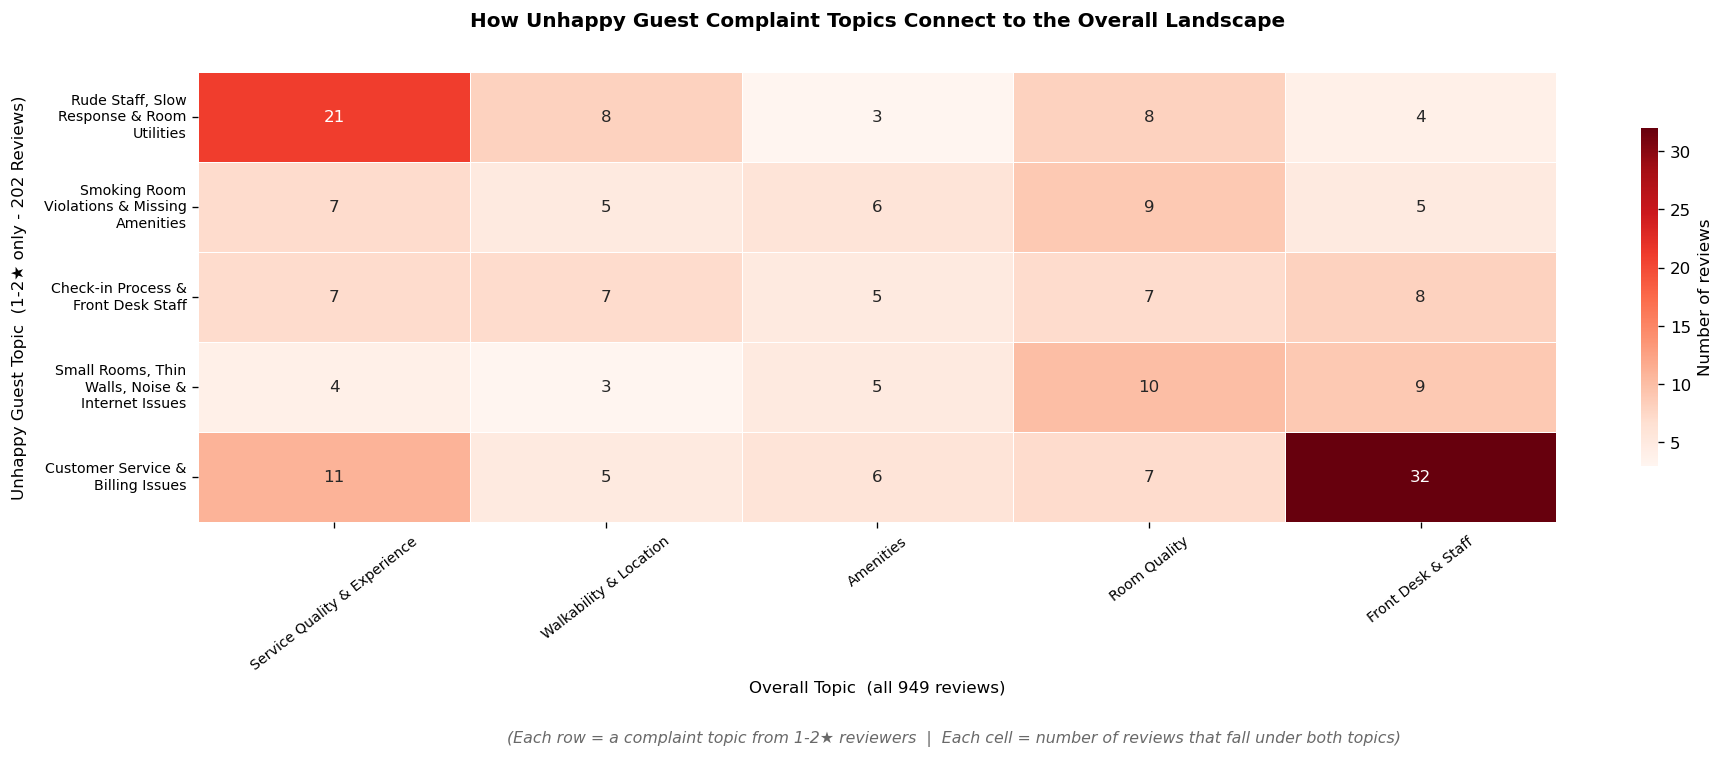

In [131]:
import textwrap

# Map each unhappy review's segment topic → its corresponding overall topic
df_unhappy_viz = df_unhappy.copy()
df_unhappy_viz['seg_topic']       = lda_unhappy.transform(dtm_unhappy).argmax(axis=1)
df_unhappy_viz['seg_topic_label'] = df_unhappy_viz['seg_topic'].map(TOPIC_LABELS_UNHAPPY)
df_unhappy_viz['all_topic_label'] = df.loc[df_unhappy_viz.index, 'dominant_topic_label']

# Cross-tabulate: unhappy topic (rows) vs all-reviews topic (columns) — raw review counts
crosstab = pd.crosstab(df_unhappy_viz['seg_topic_label'], df_unhappy_viz['all_topic_label'])

# Order rows by unhappy topic index; order columns to match the bar chart (TOPIC_LABELS_ALL order)
row_order = [TOPIC_LABELS_UNHAPPY[i] for i in sorted(TOPIC_LABELS_UNHAPPY) if TOPIC_LABELS_UNHAPPY[i] in crosstab.index]
col_order = [TOPIC_LABELS_ALL[i]     for i in sorted(TOPIC_LABELS_ALL)     if TOPIC_LABELS_ALL[i]     in crosstab.columns]
crosstab  = crosstab.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    crosstab,
    annot=True, fmt='d', cmap='Reds',
    linewidths=0.6, linecolor='white',
    cbar_kws={'label': 'Number of reviews', 'shrink': 0.75},
    ax=ax
)

# Wrap y-axis tick labels at 22 characters
wrapped_ylabels = [textwrap.fill(lbl.get_text(), width=22) for lbl in ax.get_yticklabels()]
ax.set_yticklabels(wrapped_ylabels, fontsize=8.5, va='center')

ax.set_title(
    'How Unhappy Guest Complaint Topics Connect to the Overall Landscape\n',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlabel('Overall Topic  (all 949 reviews)', fontsize=10, labelpad=5)
ax.set_ylabel('Unhappy Guest Topic  (1-2★ only - 202 Reviews)', fontsize=10, labelpad=10)
ax.tick_params(axis='x', rotation=38, labelsize=8.5)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
fig.text(
    0.5, -0.04,
    '(Each row = a complaint topic from 1-2★ reviewers  |  Each cell = number of reviews that fall under both topics)',
    ha='center', fontsize=9.5, color='dimgray', style='italic'
)
plt.savefig('fig4_unhappy_topic_map.png', bbox_inches='tight')
plt.show()

## 7. Happy vs. Unhappy - Topic Share Comparison

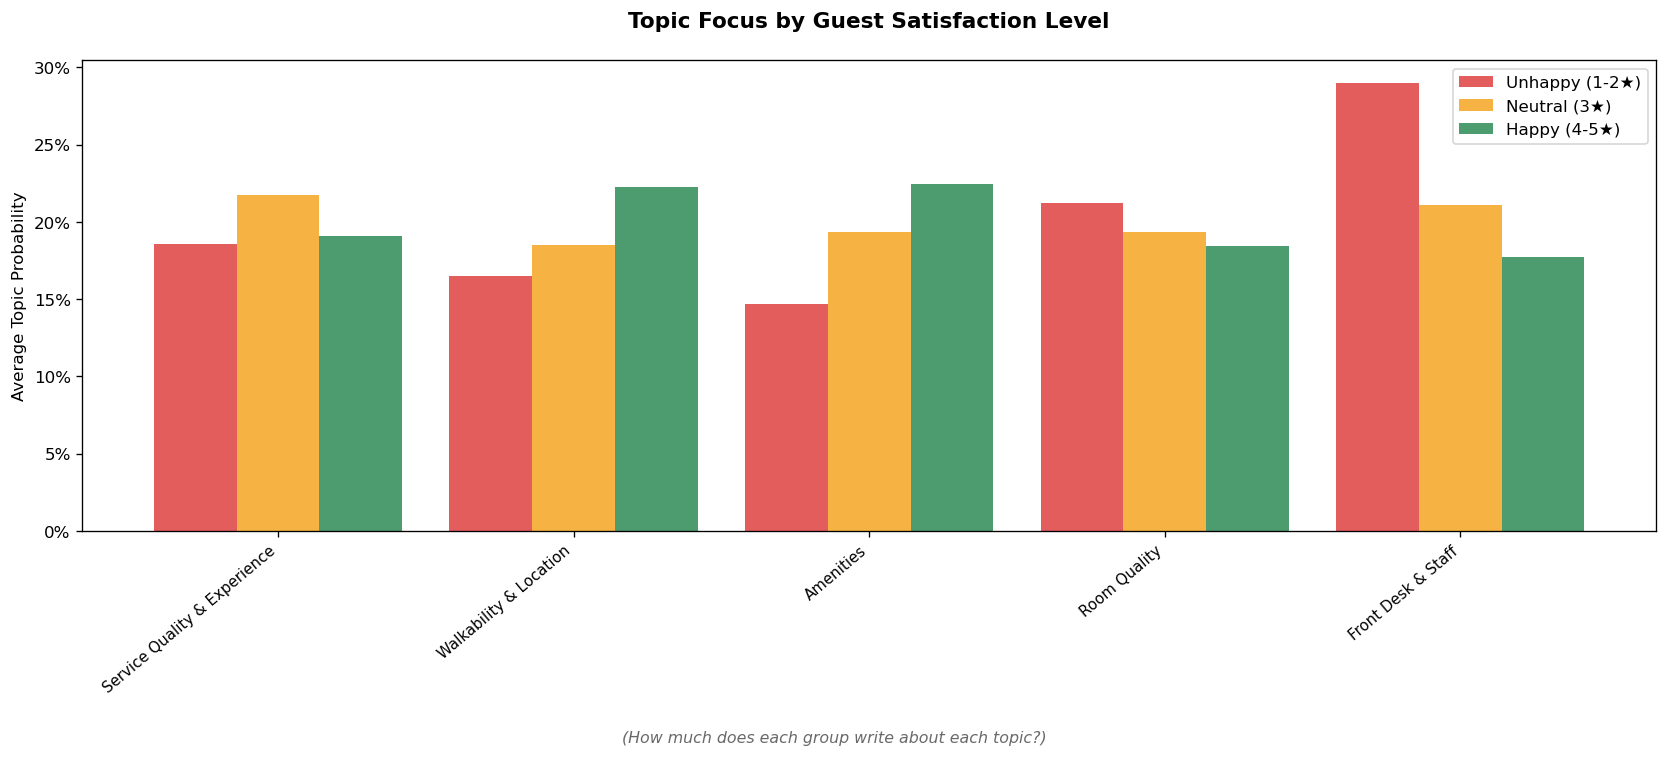

In [132]:
# Re-use the ALL-reviews LDA to compare topic distributions by segment
unhappy_topic_dist = doc_topic_all[df['sentiment'] == 'unhappy'].mean(axis=0)
happy_topic_dist   = doc_topic_all[df['sentiment'] == 'happy'].mean(axis=0)
neutral_topic_dist = doc_topic_all[df['sentiment'] == 'neutral'].mean(axis=0)

labels = [TOPIC_LABELS_ALL[i] for i in range(N_TOPICS)]
x = np.arange(len(labels))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, unhappy_topic_dist, width, label='Unhappy (1-2★)', color=PALETTE['unhappy'], alpha=0.85)
ax.bar(x,         neutral_topic_dist, width, label='Neutral (3★)',   color=PALETTE['neutral'], alpha=0.85)
ax.bar(x + width, happy_topic_dist,   width, label='Happy (4-5★)',   color=PALETTE['happy'],   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Average Topic Probability')
ax.set_title('Topic Focus by Guest Satisfaction Level\n',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
fig.text(
    0.5, -0.04,
    '(How much does each group write about each topic?)',
    ha='center', fontsize=9.5, color='dimgray', style='italic'
)
plt.savefig('fig5_topic_by_sentiment.png', bbox_inches='tight')
plt.show()

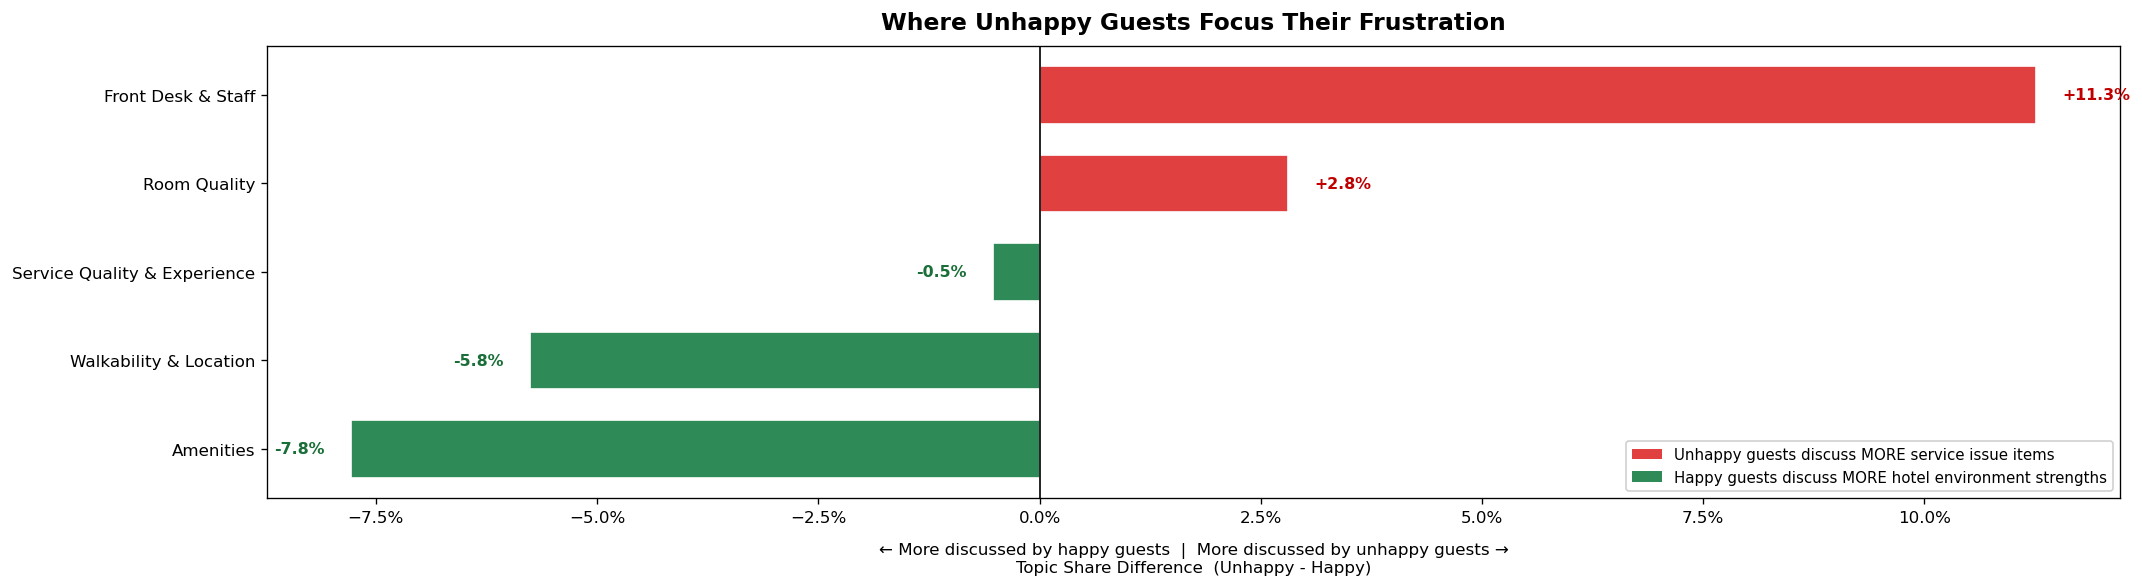

TOPIC RISK RANKING - What unhappy guests over-index on:
  #1  Front Desk & Staff                                +11.3%
  #2  Room Quality                                      +2.8%

HOTEL STRENGTHS - What happy guests over-index on:
  #1  Amenities                                         -7.8%
  #2  Walkability & Location                            -5.8%
  #3  Service Quality & Experience                      -0.5%


In [133]:
# Highlight the delta: topics that unhappy reviewers over-index on vs happy
delta = unhappy_topic_dist - happy_topic_dist
delta_series = pd.Series(delta, index=labels).sort_values()

colors_delta = ['#2E8B57' if v < 0 else '#E04040' for v in delta_series.values]

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.barh(delta_series.index, delta_series.values,
               color=colors_delta, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=1)

# Value labels on each bar
for bar, val in zip(bars, delta_series.values):
    offset = 0.003 if val >= 0 else -0.003
    ha = 'left' if val >= 0 else 'right'
    color = '#C00000' if val > 0 else '#1a6e38'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'+{val:.1%}' if val > 0 else f'{val:.1%}',
            va='center', ha=ha, fontsize=9.5, color=color, fontweight='bold')

ax.set_title('Where Unhappy Guests Focus Their Frustration',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel(
    '← More discussed by happy guests  |  More discussed by unhappy guests →\n'
    'Topic Share Difference  (Unhappy - Happy)',
    fontsize=10, labelpad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

legend_handles = [
    mpatches.Patch(facecolor='#E04040', label='Unhappy guests discuss MORE service issue items'),
    mpatches.Patch(facecolor='#2E8B57', label='Happy guests discuss MORE hotel environment strengths'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig6_topic_delta.png', bbox_inches='tight')
plt.show()

print('TOPIC RISK RANKING - What unhappy guests over-index on:')
over = delta_series[delta_series > 0].sort_values(ascending=False)
for rank, (topic, val) in enumerate(over.items(), 1):
    print(f'  #{rank}  {topic:<48}  +{val:.1%}')

print('\nHOTEL STRENGTHS - What happy guests over-index on:')
for rank, (topic, val) in enumerate(delta_series[delta_series < 0].sort_values().items(), 1):
    print(f'  #{rank}  {topic:<48}  {val:.1%}')

## 8. Other Customer Characteristics

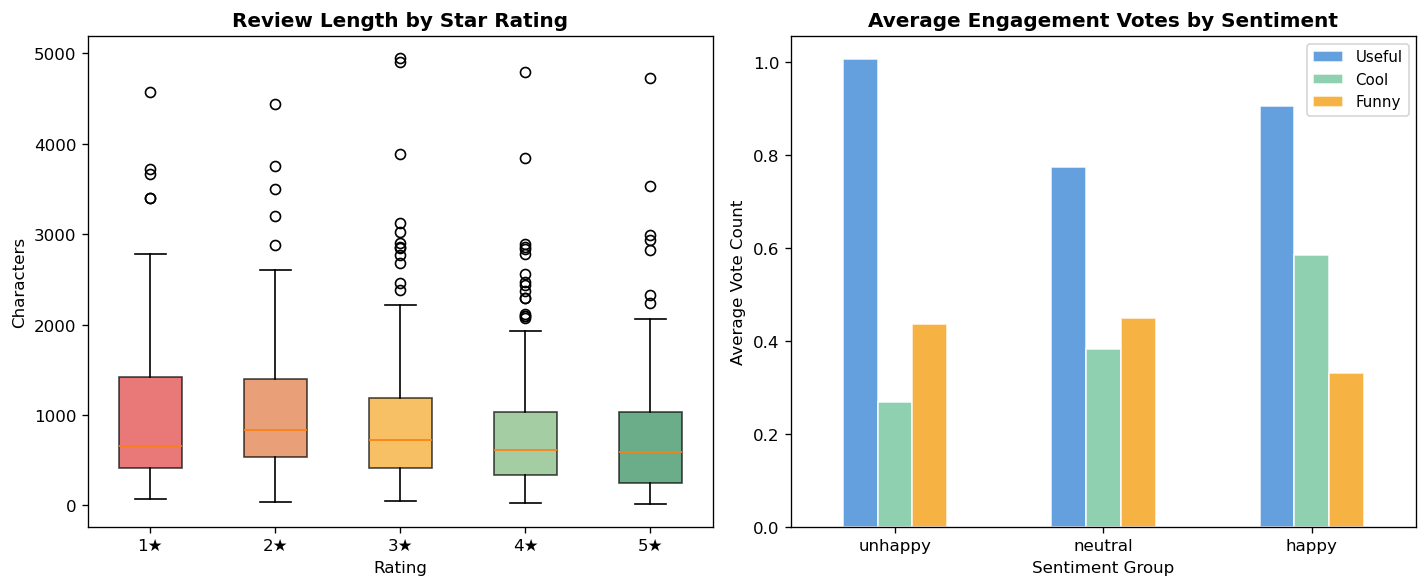

In [134]:
# Review length vs. rating
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot: review length by rating
groups = [df[df['rating'] == r]['review_length'].values for r in range(1, 6)]
bp = axes[0].boxplot(groups, labels=['1★','2★','3★','4★','5★'],
                     patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Review Length by Star Rating', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Characters')

# Useful/cool/funny engagement by sentiment
engagement = df.groupby('sentiment')[['usefulCount','coolCount','funnyCount']].mean()
engagement = engagement.loc[['unhappy','neutral','happy']]
engagement.plot(kind='bar', ax=axes[1], color=['#4A90D9','#7BC8A4','#F5A623'],
                edgecolor='white', alpha=0.85)
axes[1].set_title('Average Engagement Votes by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment Group')
axes[1].set_ylabel('Average Vote Count')
axes[1].legend(['Useful','Cool','Funny'], fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig7_characteristics.png', bbox_inches='tight')
plt.show()

In [135]:
stars_map = {'unhappy': '1-2★', 'neutral': '3★', 'happy': '4-5★'}

# Review length
length_stats = (df.groupby('sentiment')['review_length']
                  .agg(['mean', 'median', 'std'])
                  .loc[['unhappy', 'neutral', 'happy']]
                  .round(0))

print('=== REVIEW LENGTH BY GUEST SENTIMENT (characters) ===')
print(f'  {"Segment":<15}  {"Average":>8}  {"Median":>8}  {"Std Dev":>8}')
print('  ' + '-' * 44)
for seg, row in length_stats.iterrows():
    print(f'  {seg.capitalize():<9} {stars_map[seg]:<5}  {row["mean"]:>7.0f}   {row["median"]:>7.0f}   {row["std"]:>7.0f}')

u_avg = length_stats.loc['unhappy', 'mean']
h_avg = length_stats.loc['happy', 'mean']
print(f'\n  → Unhappy guests write {u_avg/h_avg:.1f}× longer reviews on average')
print(f'    ({u_avg - h_avg:.0f} extra characters of detail about what went wrong)')

# Engagement votes
eng = (df.groupby('sentiment')[['usefulCount', 'coolCount', 'funnyCount']]
         .mean()
         .loc[['unhappy', 'neutral', 'happy']]
         .round(2))

print('\n=== AVERAGE VOTES PER REVIEW BY SENTIMENT ===')
print(f'  {"Segment":<15}  {"Useful":>7}  {"Cool":>7}  {"Funny":>7}')
print('  ' + '-' * 40)
for seg, row in eng.iterrows():
    print(f'  {seg.capitalize():<9} {stars_map[seg]:<5}  {row["usefulCount"]:>7.2f}  {row["coolCount"]:>7.2f}  {row["funnyCount"]:>7.2f}')

share = df[df['sentiment'] == 'unhappy']['usefulCount'].sum() / df['usefulCount'].sum()
pct_of_reviews = (df['sentiment'] == 'unhappy').mean()
print(f'\n  → Unhappy reviews are {pct_of_reviews:.0%} of all reviews')
print(f'    but account for {share:.0%} of all "useful" votes cast')
print(f'    → One bad review carries disproportionate weight on Yelp')

=== REVIEW LENGTH BY GUEST SENTIMENT (characters) ===
  Segment           Average    Median   Std Dev
  --------------------------------------------
  Unhappy   1-2★      1074       788       853
  Neutral   3★         941       721       790
  Happy     4-5★       770       602       643

  → Unhappy guests write 1.4× longer reviews on average
    (304 extra characters of detail about what went wrong)

=== AVERAGE VOTES PER REVIEW BY SENTIMENT ===
  Segment           Useful     Cool    Funny
  ----------------------------------------
  Unhappy   1-2★      1.00     0.27     0.44
  Neutral   3★        0.77     0.38     0.45
  Happy     4-5★      0.90     0.59     0.33

  → Unhappy reviews are 21% of all reviews
    but account for 24% of all "useful" votes cast
    → One bad review carries disproportionate weight on Yelp


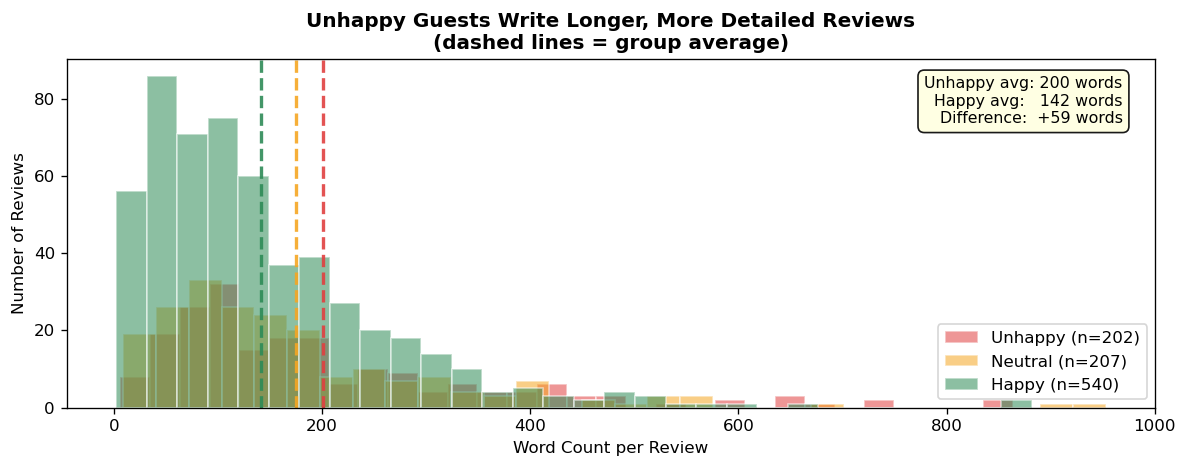

Average word count by sentiment:
  Unhappy     200 words
  Neutral     175 words
  Happy       142 words


In [136]:
# Word count (proxy for effort and detail put into a review)
df['word_count'] = df['reviewContent'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for seg, color in PALETTE.items():
    vals = df[df['sentiment'] == seg]['word_count']
    ax.hist(vals, bins=30, alpha=0.55, label=f"{seg.capitalize()} (n={len(vals):,})",
            color=color, edgecolor='white')
    ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=2, alpha=0.9)

u_mean = df[df['sentiment'] == 'unhappy']['word_count'].mean()
h_mean = df[df['sentiment'] == 'happy']['word_count'].mean()

ax.set_title('Unhappy Guests Write Longer, More Detailed Reviews\n(dashed lines = group average)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Word Count per Review')
ax.set_ylabel('Number of Reviews')
ax.legend(fontsize=10)
ax.text(0.97, 0.95,
        f'Unhappy avg: {u_mean:.0f} words\nHappy avg:   {h_mean:.0f} words\nDifference:  +{u_mean - h_mean:.0f} words',
        transform=ax.transAxes, fontsize=9.5, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('fig8_wordcount_dist.png', bbox_inches='tight')
plt.show()

print('Average word count by sentiment:')
for seg, val in df.groupby('sentiment')['word_count'].mean().loc[['unhappy','neutral','happy']].items():
    print(f'  {seg.capitalize():<10}  {val:.0f} words')

## 9. Key Findings Summary

In [137]:
print('=' * 64)
print('KEY FINDINGS - TOPIC MODELING SUMMARY')
print('=' * 64)

stars_map = {'unhappy': '1-2★', 'neutral': '3★', 'happy': '4-5★'}
for seg in ['unhappy', 'neutral', 'happy']:
    seg_df = df[df['sentiment'] == seg]
    topic_dist = doc_topic_all[df['sentiment'] == seg].mean(axis=0)
    top_topics = np.argsort(topic_dist)[::-1][:3]

    print(f'\n{seg.upper()} GUESTS ({stars_map[seg]}) - {len(seg_df)} reviews')
    for rank, t in enumerate(top_topics, 1):
        print(f'  {rank}. {TOPIC_LABELS_ALL[t]:<48} {topic_dist[t]:.1%}')

print('\n' + '=' * 64)
print('WHAT MOST CLEARLY SEPARATES UNHAPPY FROM HAPPY GUESTS?')
print('(Topic share difference: Unhappy minus Happy reviews)')
print('=' * 64)

over = delta_series[delta_series > 0].sort_values(ascending=False)
under = delta_series[delta_series < 0].sort_values()

print('\n⚠  Strongest negative differentiators:')
for rank, (topic, val) in enumerate(over.items(), 1):
    note = '  ← BIGGEST GAP' if rank == 1 else ''
    print(f'   #{rank}  {topic:<48} +{val:.1%}{note}')

print('\n✓  Strongest positive differentiators for happy guests:')
for rank, (topic, val) in enumerate(under.items(), 1):
    print(f'   #{rank}  {topic:<48} {val:.1%}')

print('\nINTERPRETATION:')
print('  • Front Desk & Staff is the clearest driver of dissatisfaction relative to happy stays.')
print('  • Room Quality is the second clearest negative differentiator.')
print('  • Amenities and Walkability/Location are the clearest positive differentiators for happy stays.')
print('  • Smoking-room mismatch and billing/fee friction appear in unhappy-only topics,')
print('    but they should be treated as narrower operational pain points within a broader')
print('    arrival/service-recovery problem rather than the top headline findings.')
print('  • Review length and vote patterns suggest unhappy reviews carry more detail and visibility,')
print('    which increases the reputational cost of unresolved service failures.')

KEY FINDINGS - TOPIC MODELING SUMMARY

UNHAPPY GUESTS (1-2★) - 202 reviews
  1. Front Desk & Staff                               29.0%
  2. Room Quality                                     21.2%
  3. Service Quality & Experience                     18.6%

NEUTRAL GUESTS (3★) - 207 reviews
  1. Service Quality & Experience                     21.7%
  2. Front Desk & Staff                               21.1%
  3. Room Quality                                     19.4%

HAPPY GUESTS (4-5★) - 540 reviews
  1. Amenities                                        22.5%
  2. Walkability & Location                           22.3%
  3. Service Quality & Experience                     19.1%

WHAT MOST CLEARLY SEPARATES UNHAPPY FROM HAPPY GUESTS?
(Topic share difference: Unhappy minus Happy reviews)

⚠  Strongest negative differentiators:
   #1  Front Desk & Staff                               +11.3%  ← BIGGEST GAP
   #2  Room Quality                                     +2.8%

✓  Strongest positive di

## 10. Recommendations Summary

In [138]:
top_risks = delta_series[delta_series > 0].sort_values(ascending=False)
top_strengths = delta_series[delta_series < 0].sort_values()

u_mean_len = df[df['sentiment'] == 'unhappy']['review_length'].mean()
h_mean_len = df[df['sentiment'] == 'happy']['review_length'].mean()
useful_share = df[df['sentiment'] == 'unhappy']['usefulCount'].sum() / df['usefulCount'].sum()
unhappy_pct = (df['sentiment'] == 'unhappy').mean()

print('=' * 64)
print('RECOMMENDATIONS FOR YOUR NEW HOTEL')
print(f'Based on {len(df):,} Yelp hotel reviews analyzed via LDA topic modeling')
print('=' * 64)

print('\n1. PRIORITIZE FRONT DESK AND CHECK-IN EXECUTION')
print(f'   Front Desk & Staff shows the largest unhappy-over-happy gap ({top_risks.iloc[0]:+.1%}).')
print('   → Focus on arrival experience, queue management, staff courtesy, issue ownership,')
print('     escalation rules, and fast service recovery when something goes wrong.')

print('\n2. FIX ROOM-QUALITY BASICS EARLY')
print(f'   Room Quality is the second largest unhappy-over-happy gap ({top_risks.iloc[1]:+.1%}).')
print('   → Prioritize noise control, room-condition checks, internet reliability, water/temperature,')
print('     and maintenance standards before opening.')

print('\n3. TREAT FEE DISCLOSURE AND BILLING AS A PROCESS-CONTROL ISSUE')
print('   Billing friction appears in unhappy-only topics, but it is better framed as part of')
print('   the broader front-desk/process problem than as the single top strategic issue.')
print('   → Communicate holds, fees, and charges clearly at booking and check-in.')

print('\n4. TIGHTEN ROOM ASSIGNMENT AND NO-SMOKING QA')
print('   Smoking-room mismatch appears as a recurring complaint theme, but it is a narrower')
print('   operational control issue than the overall front-desk and room-quality gaps.')
print('   → Use strict room-status verification, post-stay inspection, and exception handling.')

print('\n5. PRESERVE AND MARKET THE TRUE STRENGTHS')
print('   Happy guests over-index most on Amenities and Walkability & Location.')
print('   → Protect these strengths operationally and highlight them in positioning and guest messaging.')

print('\nWHY THIS MATTERS:')
print(f'  • Unhappy guests write {u_mean_len/h_mean_len:.1f}× longer reviews on average.')
print(f'  • Unhappy reviews are {unhappy_pct:.0%} of all reviews but receive {useful_share:.0%} of all useful votes.')
print('  → Preventing and resolving service failures quickly is important not just operationally,')
print('    but reputationally on public review platforms.')

print('\nBOTTOM LINE:')
print('  Launch priorities should center on front-desk execution first, room-quality consistency second,')
print('  and then tighter billing transparency and room-assignment controls as supporting safeguards.')

RECOMMENDATIONS FOR YOUR NEW HOTEL
Based on 949 Yelp hotel reviews analyzed via LDA topic modeling

1. PRIORITIZE FRONT DESK AND CHECK-IN EXECUTION
   Front Desk & Staff shows the largest unhappy-over-happy gap (+11.3%).
   → Focus on arrival experience, queue management, staff courtesy, issue ownership,
     escalation rules, and fast service recovery when something goes wrong.

2. FIX ROOM-QUALITY BASICS EARLY
   Room Quality is the second largest unhappy-over-happy gap (+2.8%).
   → Prioritize noise control, room-condition checks, internet reliability, water/temperature,
     and maintenance standards before opening.

3. TREAT FEE DISCLOSURE AND BILLING AS A PROCESS-CONTROL ISSUE
   Billing friction appears in unhappy-only topics, but it is better framed as part of
   the broader front-desk/process problem than as the single top strategic issue.
   → Communicate holds, fees, and charges clearly at booking and check-in.

4. TIGHTEN ROOM ASSIGNMENT AND NO-SMOKING QA
   Smoking-room mi

---
*Analysis complete. Figures saved as `fig1_` through `fig7_` PNG files in the working directory.*